# 加速度センサの値から角度を求める

## ライブラリのインストール
Colab.の場合は起動するたびに実行

Anacondaの場合は1度実行すれば以後実行する必要はない

In [1]:
#!pip install tensorflow 

## ライブラリのインポート

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os

## データの読み込み
学習データ

In [3]:
# 学習データの作成
with open('acc_train.txt', 'r') as f:
    lines = f.readlines()
# 入力用データとラベル（教師データ）
data = []
for l in lines:
    d = l.strip().split('\t')
    data.append(list(map(float, d)))
data = np.array(data, dtype=np.float32)
input_data, label_data = np.hsplit(data, [-1])
label_data = label_data[:, 0]  # 次元削減
train_data = np.array(input_data, dtype=np.float32)
train_label = np.array(label_data, dtype=np.float32)


検証データ（今回は使いません。）

In [4]:
# 検証データの作成
with open('acc_validation.txt', 'r') as f:
    lines = f.readlines()
data = []
for l in lines:
    d = l.strip().split('\t')
    data.append(list(map(float, d)))
data = np.array(data, dtype=np.float32)
input_data, label_data = np.hsplit(data, [-1])
label_data = label_data[:, 0]  # 次元削減
validation_data = np.array(input_data, dtype=np.float32)
validation_label = np.array(label_data, dtype=np.float32)


## ネットワークの登録

In [5]:
# ネットワークの登録
model = keras.Sequential(
    [
        keras.layers.Dense(3, activation='relu',kernel_initializer=keras.initializers.TruncatedNormal(mean=0.0, stddev=0.05, seed=1)),
        keras.layers.Dense(3, activation='relu',kernel_initializer=keras.initializers.TruncatedNormal(mean=0.0, stddev=0.05, seed=1)),
        keras.layers.Dense(1,kernel_initializer=keras.initializers.TruncatedNormal(mean=0.0, stddev=0.05, seed=1)),
    ]
)


## TensorBoard用
今回は使用しない

In [6]:
# TensorBoard用コールバック
tb_cb = keras.callbacks.TensorBoard(log_dir='log', histogram_freq=1)

## モデルの設定
最適化関数と損失関数の設定

In [7]:
model.compile(
    optimizer='adam', loss='mse', metrics=['mse']
)

## 学習の開始

In [8]:
model.fit(
    train_data,
    train_label,
    epochs=1000,# epoch数
    batch_size=8,
#    callbacks=[tb_cb],
    validation_data=(validation_data, validation_label),
)

Epoch 1/1000
3/3 [==============================] - 2s 73ms/step - loss: 0.5255 - mse: 0.5255 - val_loss: 0.5245 - val_mse: 0.5245
Epoch 2/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.5246 - mse: 0.5246 - val_loss: 0.5239 - val_mse: 0.5239
Epoch 3/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.5238 - mse: 0.5238 - val_loss: 0.5232 - val_mse: 0.5232
Epoch 4/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.5232 - mse: 0.5232 - val_loss: 0.5226 - val_mse: 0.5226
Epoch 5/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.5225 - mse: 0.5225 - val_loss: 0.5218 - val_mse: 0.5218
Epoch 6/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.5218 - mse: 0.5218 - val_loss: 0.5210 - val_mse: 0.5210
Epoch 7/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.5208 - mse: 0.5208 - val_loss: 0.5200 - val_mse: 0.5200
Epoch 8/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.5197 - m

3/3 [==============================] - 0s 11ms/step - loss: 0.3156 - mse: 0.3156 - val_loss: 0.3142 - val_mse: 0.3142
Epoch 64/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.3137 - mse: 0.3137 - val_loss: 0.3123 - val_mse: 0.3123
Epoch 65/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.3120 - mse: 0.3120 - val_loss: 0.3104 - val_mse: 0.3104
Epoch 66/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.3101 - mse: 0.3101 - val_loss: 0.3085 - val_mse: 0.3085
Epoch 67/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.3079 - mse: 0.3079 - val_loss: 0.3066 - val_mse: 0.3066
Epoch 68/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.3060 - mse: 0.3060 - val_loss: 0.3047 - val_mse: 0.3047
Epoch 69/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.3041 - mse: 0.3041 - val_loss: 0.3029 - val_mse: 0.3029
Epoch 70/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.3025 - mse: 0.

Epoch 125/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.2132 - mse: 0.2132 - val_loss: 0.2122 - val_mse: 0.2122
Epoch 126/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.2116 - mse: 0.2116 - val_loss: 0.2108 - val_mse: 0.2108
Epoch 127/1000
3/3 [==============================] - ETA: 0s - loss: 0.2119 - mse: 0.211 - 0s 11ms/step - loss: 0.2104 - mse: 0.2104 - val_loss: 0.2094 - val_mse: 0.2094
Epoch 128/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.2091 - mse: 0.2091 - val_loss: 0.2080 - val_mse: 0.2080
Epoch 129/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.2076 - mse: 0.2076 - val_loss: 0.2068 - val_mse: 0.2068
Epoch 130/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.2066 - mse: 0.2066 - val_loss: 0.2056 - val_mse: 0.2056
Epoch 131/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.2052 - mse: 0.2052 - val_loss: 0.2042 - val_mse: 0.2042
Epoch 132/1000
3/3 [===========

3/3 [==============================] - 0s 12ms/step - loss: 0.1418 - mse: 0.1418 - val_loss: 0.1410 - val_mse: 0.1410
Epoch 187/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.1406 - mse: 0.1406 - val_loss: 0.1399 - val_mse: 0.1399
Epoch 188/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.1400 - mse: 0.1400 - val_loss: 0.1389 - val_mse: 0.1389
Epoch 189/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.1386 - mse: 0.1386 - val_loss: 0.1378 - val_mse: 0.1378
Epoch 190/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.1376 - mse: 0.1376 - val_loss: 0.1368 - val_mse: 0.1368
Epoch 191/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.1365 - mse: 0.1365 - val_loss: 0.1358 - val_mse: 0.1358
Epoch 192/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.1357 - mse: 0.1357 - val_loss: 0.1349 - val_mse: 0.1349
Epoch 193/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.1347 - 

Epoch 248/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0870 - mse: 0.0870 - val_loss: 0.0865 - val_mse: 0.0865
Epoch 249/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0863 - mse: 0.0863 - val_loss: 0.0858 - val_mse: 0.0858
Epoch 250/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0859 - mse: 0.0859 - val_loss: 0.0852 - val_mse: 0.0852
Epoch 251/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.0850 - mse: 0.0850 - val_loss: 0.0844 - val_mse: 0.0844
Epoch 252/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0842 - mse: 0.0842 - val_loss: 0.0836 - val_mse: 0.0836
Epoch 253/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0837 - mse: 0.0837 - val_loss: 0.0829 - val_mse: 0.0829
Epoch 254/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0827 - mse: 0.0827 - val_loss: 0.0822 - val_mse: 0.0822
Epoch 255/1000
3/3 [==============================] - 0s 13ms/step - 

...

Epoch 739/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0077 - mse: 0.0077 - val_loss: 0.0078 - val_mse: 0.0078
Epoch 740/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0078 - mse: 0.0078 - val_loss: 0.0077 - val_mse: 0.0077
Epoch 741/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0077 - mse: 0.0077 - val_loss: 0.0074 - val_mse: 0.0074
Epoch 742/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0074 - val_mse: 0.0074
Epoch 743/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0075 - mse: 0.0075 - val_loss: 0.0077 - val_mse: 0.0077
Epoch 744/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0077 - mse: 0.0077 - val_loss: 0.0078 - val_mse: 0.0078
Epoch 745/1000
3/3 [==============================] - 0s 13ms/step - loss: 0.0079 - mse: 0.0079 - val_loss: 0.0077 - val_mse: 0.0077
Epoch 746/1000
3/3 [==============================] - 0s 12ms/step - 

3/3 [==============================] - 0s 13ms/step - loss: 0.0075 - mse: 0.0075 - val_loss: 0.0072 - val_mse: 0.0072
Epoch 801/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0073 - val_mse: 0.0073
Epoch 802/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0076 - mse: 0.0076 - val_loss: 0.0074 - val_mse: 0.0074
Epoch 803/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0072 - val_mse: 0.0072
Epoch 804/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0072 - val_mse: 0.0072
Epoch 805/1000
3/3 [==============================] - 2s 972ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0072 - val_mse: 0.0072
Epoch 806/1000
3/3 [==============================] - 0s 14ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0072 - val_mse: 0.0072
Epoch 807/1000
3/3 [==============================] - 0s 15ms/step - loss: 0.0074 -

Epoch 862/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0071 - mse: 0.0071 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 863/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0071 - mse: 0.0071 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 864/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0071 - val_mse: 0.0071
Epoch 865/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0071 - mse: 0.0071 - val_loss: 0.0073 - val_mse: 0.0073
Epoch 866/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0073 - val_mse: 0.0073
Epoch 867/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0073 - mse: 0.0073 - val_loss: 0.0071 - val_mse: 0.0071
Epoch 868/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 869/1000
3/3 [==============================] - 0s 12ms/step - 

3/3 [==============================] - 0s 11ms/step - loss: 0.0069 - mse: 0.0069 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 924/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 925/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0071 - mse: 0.0071 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 926/1000
3/3 [==============================] - 0s 14ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 927/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0069 - mse: 0.0069 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 928/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0068 - mse: 0.0068 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 929/1000
3/3 [==============================] - 0s 14ms/step - loss: 0.0069 - mse: 0.0069 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 930/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0070 - 

Epoch 985/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0072 - mse: 0.0072 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 986/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0068 - mse: 0.0068 - val_loss: 0.0068 - val_mse: 0.0068
Epoch 987/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0068 - mse: 0.0068 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 988/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0070 - val_mse: 0.0070
Epoch 989/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0070 - mse: 0.0070 - val_loss: 0.0069 - val_mse: 0.0069
Epoch 990/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0069 - mse: 0.0069 - val_loss: 0.0068 - val_mse: 0.0068
Epoch 991/1000
3/3 [==============================] - 0s 11ms/step - loss: 0.0068 - mse: 0.0068 - val_loss: 0.0068 - val_mse: 0.0068
Epoch 992/1000
3/3 [==============================] - 0s 12ms/step - 

## モデルの保存と読み込み

In [9]:
#model.save(os.path.join('acc_result', 'outmodel'))  # モデルの保存
#model = keras.models.load_model(os.path.join('acc_result', 'outmodel'))  # モデルの読み込み

## テストデータの読み込み

In [10]:
with open('acc_test.txt', 'r') as f:  # ファイルのオープン
    lines = f.readlines()  # ファイルから読み込み

data = []
for l in lines:
    d = l.strip().split()  # タブでデータを分ける
    data.append(list(map(float, d)))  # データの変換と追加
#    print(d, data)
test_data = np.array(data, dtype=np.float32)


## テストデータを用いた予測
予測値の計算

In [11]:
predictions = model.predict(test_data)
for i, prediction in enumerate(predictions):
#    print(f'{test_data[i][0]},{prediction[0]}')
    print(f'{prediction[0]}')


0.9368491768836975
0.9368491768836975
0.9368491768836975
0.7990607619285583
0.6591174602508545
0.5191741585731506
0.3792308568954468
0.2392876148223877
0.09934431314468384
-0.040598928928375244
-0.18054240942001343
-0.3204856514930725
-0.4604288935661316
-0.6003722548484802
-0.7403153777122498
-0.8802587389945984
-1.0202021598815918
-1.1601452827453613


予測値のグラフ表示

In [12]:
import matplotlib.pyplot as plt

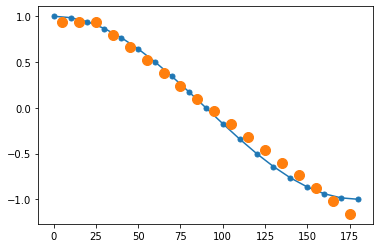

In [13]:
fig = plt.figure()
plt.plot(input_data, label_data, marker="o", markersize=5)
plt.plot(test_data, predictions, marker='o',linestyle='None', markersize=10)

グラフの保存

In [14]:
fig.savefig("acc_img.png")#pngで保存
#fig.savefig("acc_img.pdf")#pdfで保存

## 重みの表示

In [15]:
l = model.layers[0]
print(len(l.get_weights()))
print(l.get_weights()[0])
print(l.get_weights()[1])
l = model.layers[1]
print(len(l.get_weights()))
print(l.get_weights()[0])
print(l.get_weights()[1])
l = model.layers[2]
print(len(l.get_weights()))
print(l.get_weights()[0])
print(l.get_weights()[1])

2
[[-0.00832004 -0.02465083  0.18041164]]
[-0.00903932  0.         -0.84503967]
2
[[ 0.00633252 -0.01172646  0.02160712]
 [-0.03944233 -0.04549282 -0.01995825]
 [-0.00190596  0.20906988 -0.01103863]]
[ 0.         -0.7721015  -0.00974721]
2
[[ 0.00633252]
 [-0.37101892]
 [ 0.02299127]]
[0.9368492]
